<a href="https://colab.research.google.com/github/ayaanb10/MLCS_Project_Sem-VI/blob/main/MLCS_Exp2345.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exp 4


Dataset Shape: (25, 4)

Missing Values:
 url              0
email_subject    0
email_body       0
label            0
dtype: int64

Class Distribution:
 label
False    13
True     12
Name: count, dtype: int64


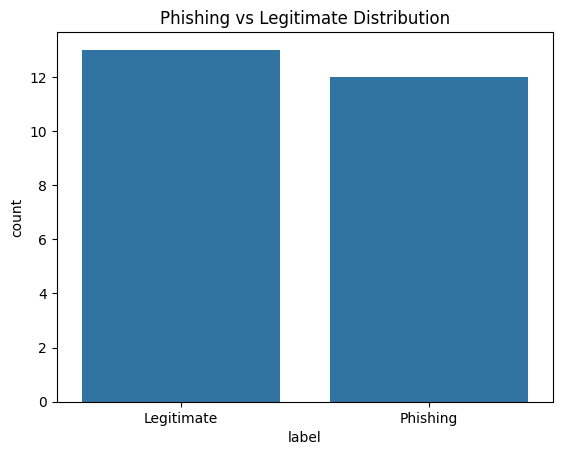

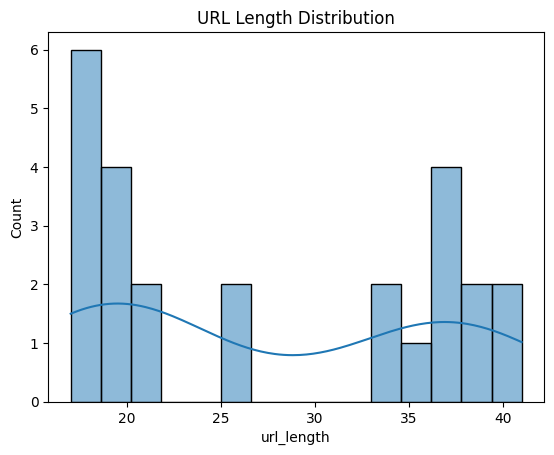

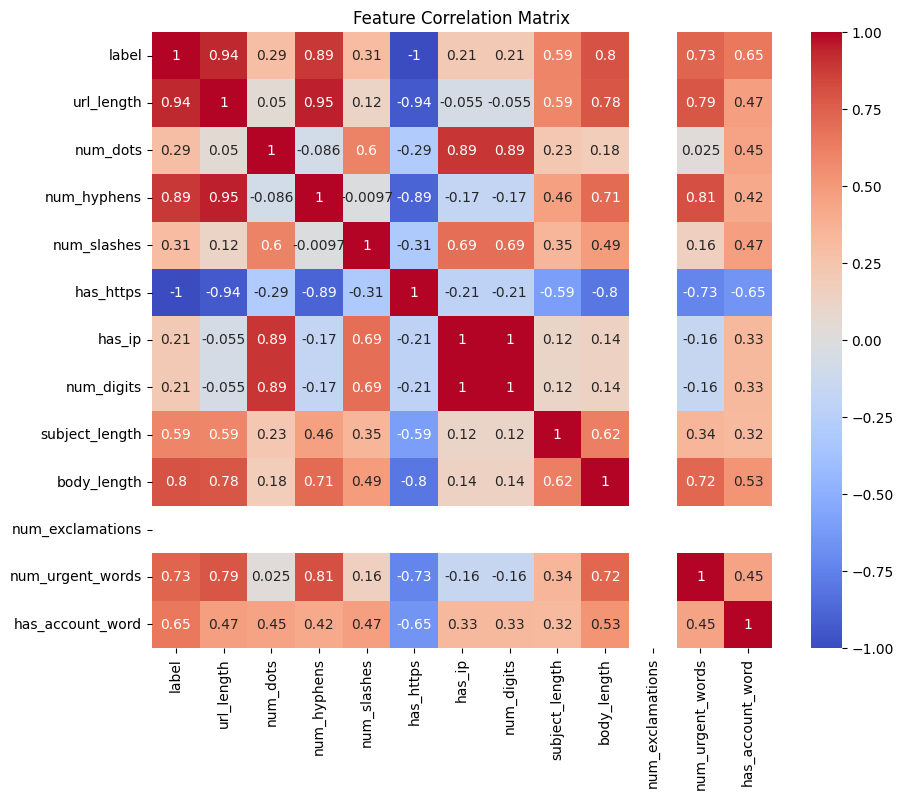

Feature Matrix Shape: (25, 12)
Training Size: (20, 12)
Testing Size: (5, 12)

Preprocessing Completed Successfully


In [6]:
# Feature Enginnering: Exp4

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/MLCS_datset.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['label'].value_counts())

df.head()

# Convert label to binary
df['label'] = df['label'].astype(str).str.lower().map({'true': 1, 'false': 0})

# URL Feature Engineering
def extract_url_features(url):
    parsed = urlparse(url)

    return pd.Series({
        'url_length': len(url),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_slashes': url.count('/'),
        'has_https': 1 if parsed.scheme == 'https' else 0,
        'has_ip': 1 if re.match(r'\d+\.\d+\.\d+\.\d+', parsed.netloc) else 0,
        'num_digits': sum(c.isdigit() for c in url),
    })

url_features = df['url'].apply(extract_url_features)

# Email Feature Engineering
def extract_email_features(row):
    subject = str(row['email_subject']).lower()
    body = str(row['email_body']).lower()

    urgent_keywords = ['urgent', 'verify', 'immediately', 'suspend', 'locked', 'reset', 'confirm']

    return pd.Series({
        'subject_length': len(subject),
        'body_length': len(body),
        'num_exclamations': subject.count('!') + body.count('!'),
        'num_urgent_words': sum(word in subject + body for word in urgent_keywords),
        'has_account_word': 1 if 'account' in subject + body else 0
    })

email_features = df.apply(extract_email_features, axis=1)


# Combine all features
df = pd.concat([df, url_features, email_features], axis=1)

df.head()

# Class distribution
plt.figure()
sns.countplot(x=df['label'])
plt.title("Phishing vs Legitimate Distribution")
plt.xticks([0,1], ['Legitimate', 'Phishing'])
plt.show()

# URL length distribution
plt.figure()
sns.histplot(df['url_length'], bins=15, kde=True)
plt.title("URL Length Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(['url','email_subject','email_body'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

X = df.drop(['url', 'email_subject', 'email_body', 'label'], axis=1)
y = df['label']

print("Feature Matrix Shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully")

## Exp 5


In [9]:
# Model Implementation:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy: (Baseline Model)", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: (Baseline Model) 1.0

Confusion Matrix:
 [[2 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy: (Main MOdel)", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: (Main MOdel) 1.0

Confusion Matrix:
 [[2 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



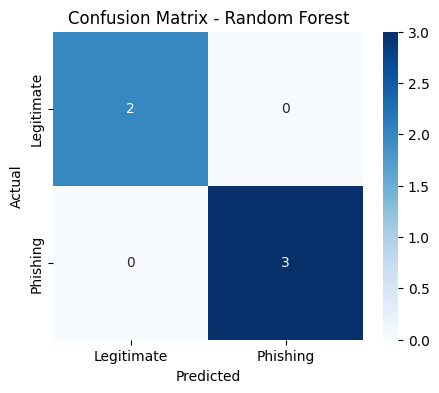

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [12]:
# Hyperparameter Tuning:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}
